# RAG Eval — Шаг 3: Метрики Generation (по моделям)

Для каждой модели из списка:
1. Запускаем полный пайплайн `GraphRAG.query()` с оптимальным `top_k` (из Notebook 2)
2. Оцениваем ответ через **LLM-as-a-judge** (`openai/gpt-5.1`):
   - `faithfulness` — факты ответа подтверждены контекстом
   - `relevance` — ответ отвечает на вопрос
   - `completeness` — ответ покрывает все аспекты
   - `coherence` — связность и читаемость
   - `accuracy` — соответствие эталонному ответу
3. Сравниваем модели по всем метрикам.

Результаты: `metric_results/rag/generator/`

In [1]:
import os
import sys
import json
import time
import logging
from pathlib import Path
from datetime import datetime
from threading import Lock
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm import tqdm
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
load_dotenv(PROJECT_ROOT / '.env')

from zettelkasten.graph_rag import GraphRAG
from zettelkasten.linker import LocalEmbeddingModel
from storage.neo4j.client import get_neo4j_client
from storage.neo4j.repository import ZettelRepository
from config.settings import settings

logging.basicConfig(level=logging.WARNING)
print('✅ imports ok')

/Users/nastya/github/Executive_Exocortex/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ imports ok


In [2]:
EVAL_USER_ID = 'linker_eval_gpt-5.2'
JUDGE_MODEL  = 'openai/gpt-5.1'
MAX_WORKERS  = 5    # параллельность для каждой модели
TEMPERATURE  = 0.3

# Модели для тестирования
LLM_MODELS = [
    'openai/gpt-4o-mini',
    'google/gemini-2.5-flash',
    'anthropic/claude-haiku-4.5',
]

QA_DATASET_PATH    = Path('synthetic_datasets/rag_qa_dataset.xlsx')
RETRIEVAL_DIR      = Path('metric_results/rag/retrieval')
OUTPUT_DIR         = Path('metric_results/rag/generator')
FIGURES_DIR        = OUTPUT_DIR / 'figures'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Загружаем best_k из Notebook 2
best_k_path = RETRIEVAL_DIR / 'best_k.json'
if best_k_path.exists():
    with open(best_k_path) as f:
        best_k_data = json.load(f)
    BEST_K = best_k_data['best_k']
    print(f'Loaded best_k={BEST_K} from Notebook 2 (F1={best_k_data["f1"]:.4f})')
else:
    BEST_K = 5
    print(f'best_k.json not found, using default BEST_K={BEST_K}')

SIMILARITY_THRESHOLD = 0.20
print(f'Models to evaluate: {LLM_MODELS}')

Loaded best_k=7 from Notebook 2 (F1=0.0732)
Models to evaluate: ['openai/gpt-4o-mini', 'google/gemini-2.5-flash', 'anthropic/claude-haiku-4.5']


In [3]:
df_qa   = pd.read_excel(QA_DATASET_PATH)
df_eval = df_qa[df_qa['n_gt_zettels'] > 0].reset_index(drop=True)

print(f'Dataset: {len(df_qa)} total, {len(df_eval)} with GT zettels')
df_eval[['question_id', 'question', 'question_type']].head(3)

Dataset: 199 total, 131 with GT zettels


,question_id,question,question_type
0,Q-0A1D247E,"Напомни, какой именно лимит на экспресс-достав...",factual
1,Q-FB4EB54F,"Напомни, какую оценку по потере MRR называла К...",factual
2,Q-C1D4BCA0,"Напомни, до какой даты мы договорились замороз...",factual


In [4]:
class GenerationEvalResult(BaseModel):
    faithfulness:  float = Field(ge=0.0, le=1.0, description="Все факты ответа подтверждены контекстом (0 — всё выдумано, 1 — полностью достоверно)")
    relevance:     float = Field(ge=0.0, le=1.0, description="Насколько ответ отвечает на заданный вопрос (0 — совсем не по теме, 1 — точно в точку)")
    completeness:  float = Field(ge=0.0, le=1.0, description="Полнота покрытия всех аспектов вопроса (0 — пропущено всё важное, 1 — ничего не упущено)")
    coherence:     float = Field(ge=0.0, le=1.0, description="Связность и читаемость ответа (0 — бессмысленный текст, 1 — отлично структурирован)")
    accuracy:      float = Field(ge=0.0, le=1.0, description="Соответствие фактов в ответе эталонному ответу (0 — все факты неверны, 1 — всё точно)")
    hallucinations: float = Field(ge=0.0, le=1.0, description="Доля галлюцинаций — фактов, которых нет в контексте (0 — галлюцинаций нет, 1 — всё выдумано)")
    brief_comment: str = Field(description="1-2 предложения: главные плюсы и минусы ответа")


JUDGE_SYSTEM_PROMPT = """Ты — эксперт-аналитик по оценке качества ответов RAG-систем.
Ты получаешь:
- ВОПРОС пользователя
- КОНТЕКСТ — фрагменты из базы знаний, которые система нашла
- ОТВЕТ СИСТЕМЫ — то, что система сгенерировала
- ЭТАЛОННЫЙ ОТВЕТ — идеальный ответ на основе заметок

Оцени ОТВЕТ СИСТЕМЫ по 6 критериям строго от 0 до 1:

1. faithfulness [0, 1]: все факты ответа присутствуют в КОНТЕКСТЕ? (не в эталоне, а в контексте!)
2. relevance [0, 1]: ответ действительно отвечает на поставленный ВОПРОС?
3. completeness [0, 1]: ответ покрывает все важные аспекты из ЭТАЛОННОГО ОТВЕТА?
4. coherence [0, 1]: текст ответа связный, структурированный, читаемый?
5. accuracy [0, 1]: факты в ОТВЕТЕ совпадают с ЭТАЛОННЫМ ОТВЕТОМ?
6. hallucinations [0, 1]: доля утверждений в ответе, которых НЕТ в контексте?

Будь строгим. Оценка 0.9+ — только если ответ действительно отличный.
Дай краткий комментарий (1-2 предложения) о главных достоинствах и недостатках."""


def evaluate_with_judge(
    question: str,
    context_str: str,
    system_answer: str,
    reference_answer: str,
) -> GenerationEvalResult | None:
    judge_llm = ChatOpenAI(
        model=JUDGE_MODEL,
        temperature=0,
        api_key=os.getenv('LLM_API_KEY'),
        base_url=os.getenv('LLM_BASE_URL'),
    )
    user_content = (
        f"ВОПРОС:\n{question}\n\n"
        f"КОНТЕКСТ (из базы знаний):\n{context_str}\n\n"
        f"ОТВЕТ СИСТЕМЫ:\n{system_answer}\n\n"
        f"ЭТАЛОННЫЙ ОТВЕТ:\n{reference_answer}"
    )
    try:
        return judge_llm.with_structured_output(GenerationEvalResult).invoke([
            SystemMessage(content=JUDGE_SYSTEM_PROMPT),
            HumanMessage(content=user_content),
        ])
    except Exception as e:
        logging.error(f'Judge error: {e}')
        return None


print('✅ Judge schema and function ready')

✅ Judge schema and function ready


In [5]:
embedding_model = LocalEmbeddingModel()
neo4j_client    = get_neo4j_client()
repository      = ZettelRepository(neo4j_client)

EVAL_METRICS = ['faithfulness', 'relevance', 'completeness', 'coherence', 'accuracy', 'hallucinations']
all_raw_records = []
save_lock = Lock()


def evaluate_single(row: dict, rag: GraphRAG, model_name: str) -> dict | None:
    question_id      = row['question_id']
    question         = row['question']
    reference_answer = row['reference_answer']

    t0 = time.time()
    try:
        response = rag.query(
            EVAL_USER_ID, question,
            similarity_threshold=SIMILARITY_THRESHOLD,
        )
        latency_ms  = int((time.time() - t0) * 1000)
        answer      = response.answer
        context_str = response.context.to_context_string()
        n_nodes     = len(response.context.all_nodes)
    except Exception as e:
        logging.error(f'RAG error [{model_name}] {question_id}: {e}')
        return None

    eval_result = evaluate_with_judge(question, context_str, answer, reference_answer)
    if eval_result is None:
        return None

    return {
        'model_name':       model_name,
        'question_id':      question_id,
        'question':         question,
        'question_type':    row.get('question_type', ''),
        'note_domain':      row.get('note_domain', ''),
        'system_answer':    answer,
        'reference_answer': reference_answer,
        'n_context_nodes':  n_nodes,
        'latency_ms':       latency_ms,
        'faithfulness':     eval_result.faithfulness,
        'relevance':        eval_result.relevance,
        'completeness':     eval_result.completeness,
        'coherence':        eval_result.coherence,
        'accuracy':         eval_result.accuracy,
        'hallucinations':   eval_result.hallucinations,
        'brief_comment':    eval_result.brief_comment,
        'evaluated_at':     datetime.now().isoformat(),
    }


for model_name in LLM_MODELS:
    print(f'\n{"="*60}')
    print(f'Model: {model_name}')
    print(f'{"="*60}')

    rag = GraphRAG(
        embedding_model=embedding_model,
        repository=repository,
        model_name=model_name,
        temperature=TEMPERATURE,
        similarity_threshold=SIMILARITY_THRESHOLD,
    )
    # Переопределяем search_limit на best_k
    rag.retriever.search_limit = BEST_K

    rows = df_eval.to_dict('records')
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = {
            executor.submit(evaluate_single, r, rag, model_name): r['question_id']
            for r in rows
        }
        for future in tqdm(as_completed(futures), total=len(futures), desc=model_name):
            result = future.result()
            if result is not None:
                with save_lock:
                    all_raw_records.append(result)

df_gen_raw = pd.DataFrame(all_raw_records)
print(f'\nTotal records: {len(df_gen_raw)}')
df_gen_raw.groupby('model_name')[EVAL_METRICS].mean().round(3)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9740.99it/s]
/Users/nastya/github/Executive_Exocortex/zettelkasten/linker.py:84: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  return self.model.get_sentence_embedding_dimension()


[EmbeddingModel] intfloat/multilingual-e5-base загружена за 8.2с (dim=768, device=mps)
obunar63
[Neo4j] Подключено к bolt://localhost:7687

Model: openai/gpt-4o-mini


openai/gpt-4o-mini: 100%|██████████| 131/131 [02:44<00:00,  1.26s/it]



Model: google/gemini-2.5-flash


google/gemini-2.5-flash:  11%|█         | 14/131 [00:21<01:44,  1.12it/s]WARNING:neo4j.notifications:Received notification from DBMS server: <GqlStatusObject gql_status='01N51', status_description='warn: relationship type does not exist. The relationship type `RELATED_TO` does not exist. Verify that the spelling is correct.', position=<SummaryInputPosition line=2, column=71, offset=71>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 71, 'line': 2, 'column': 71}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\n        MATCH (z:Zettel {zettel_id: $zettel_id, user_id: $user_id})-[:RELATED_TO*1..1]-(related:Zettel {user_id: $user_id})\n        WHERE related.zettel_id <> $zettel_id\n        RETURN DISTINCT related as z\n     


Model: anthropic/claude-haiku-4.5


anthropic/claude-haiku-4.5:   4%|▍         | 5/131 [00:09<02:42,  1.29s/it]WARNING:neo4j.notifications:Received notification from DBMS server: <GqlStatusObject gql_status='01N51', status_description='warn: relationship type does not exist. The relationship type `RELATED_TO` does not exist. Verify that the spelling is correct.', position=<SummaryInputPosition line=2, column=71, offset=71>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 71, 'line': 2, 'column': 71}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\n        MATCH (z:Zettel {zettel_id: $zettel_id, user_id: $user_id})-[:RELATED_TO*1..1]-(related:Zettel {user_id: $user_id})\n        WHERE related.zettel_id <> $zettel_id\n        RETURN DISTINCT related as z\n   


Total records: 299


,faithfulness,relevance,completeness,coherence,accuracy,hallucinations
model_name,,,,,,
anthropic/claude-haiku-4.5,0.972,0.896,0.290,0.987,0.390,0.031
google/gemini-2.5-flash,0.972,0.882,0.256,0.979,0.344,0.029
openai/gpt-4o-mini,0.934,0.880,0.230,0.987,0.426,0.070


In [6]:
# Сохраняем сырые результаты
raw_path = OUTPUT_DIR / 'generation_raw.xlsx'
df_gen_raw.to_excel(raw_path, index=False)
print(f'Raw results saved: {raw_path}')

# Сводная таблица по моделям
summary_gen = df_gen_raw.groupby('model_name').agg(
    n_questions=('question_id', 'count'),
    faithfulness_mean=('faithfulness', 'mean'),
    faithfulness_std=('faithfulness', 'std'),
    relevance_mean=('relevance', 'mean'),
    relevance_std=('relevance', 'std'),
    completeness_mean=('completeness', 'mean'),
    completeness_std=('completeness', 'std'),
    coherence_mean=('coherence', 'mean'),
    coherence_std=('coherence', 'std'),
    accuracy_mean=('accuracy', 'mean'),
    accuracy_std=('accuracy', 'std'),
    hallucinations_mean=('hallucinations', 'mean'),
    hallucinations_std=('hallucinations', 'std'),
    latency_ms_mean=('latency_ms', 'mean'),
    latency_ms_p95=('latency_ms', lambda x: np.percentile(x, 95)),
).round(4)

# Считаем overall score (среднее по позитивным метрикам минус галлюцинации)
pos_metrics = ['faithfulness_mean', 'relevance_mean', 'completeness_mean',
               'coherence_mean', 'accuracy_mean']
summary_gen['overall_score'] = (
    summary_gen[pos_metrics].mean(axis=1) * 0.85
    + (1 - summary_gen['hallucinations_mean']) * 0.15
).round(4)

summary_gen = summary_gen.sort_values('overall_score', ascending=False)

summary_path = OUTPUT_DIR / 'generation_summary.xlsx'
summary_gen.to_excel(summary_path)
print(f'Summary saved: {summary_path}')
print('\n=== Summary by model ===')
display(summary_gen)

Raw results saved: metric_results/rag/generator/generation_raw.xlsx
Summary saved: metric_results/rag/generator/generation_summary.xlsx

=== Summary by model ===


,n_questions,faithfulness_mean,faithfulness_std,relevance_mean,relevance_std,completeness_mean,completeness_std,coherence_mean,coherence_std,accuracy_mean,accuracy_std,hallucinations_mean,hallucinations_std,latency_ms_mean,latency_ms_p95,overall_score
model_name,,,,,,,,,,,,,,,,
anthropic/claude-haiku-4.5,83,0.9723,0.0874,0.8958,0.1205,0.2898,0.3883,0.9867,0.0260,0.3898,0.3740,0.0313,0.0893,4255.3976,6072.0,0.7462
google/gemini-2.5-flash,85,0.9724,0.0911,0.8818,0.1258,0.2565,0.3539,0.9792,0.0320,0.3435,0.3558,0.0288,0.0914,2445.6353,4303.4,0.7294
openai/gpt-4o-mini,131,0.9340,0.1948,0.8802,0.1647,0.2302,0.3799,0.9874,0.0347,0.4260,0.4171,0.0698,0.1979,3211.5649,5158.0,0.7274


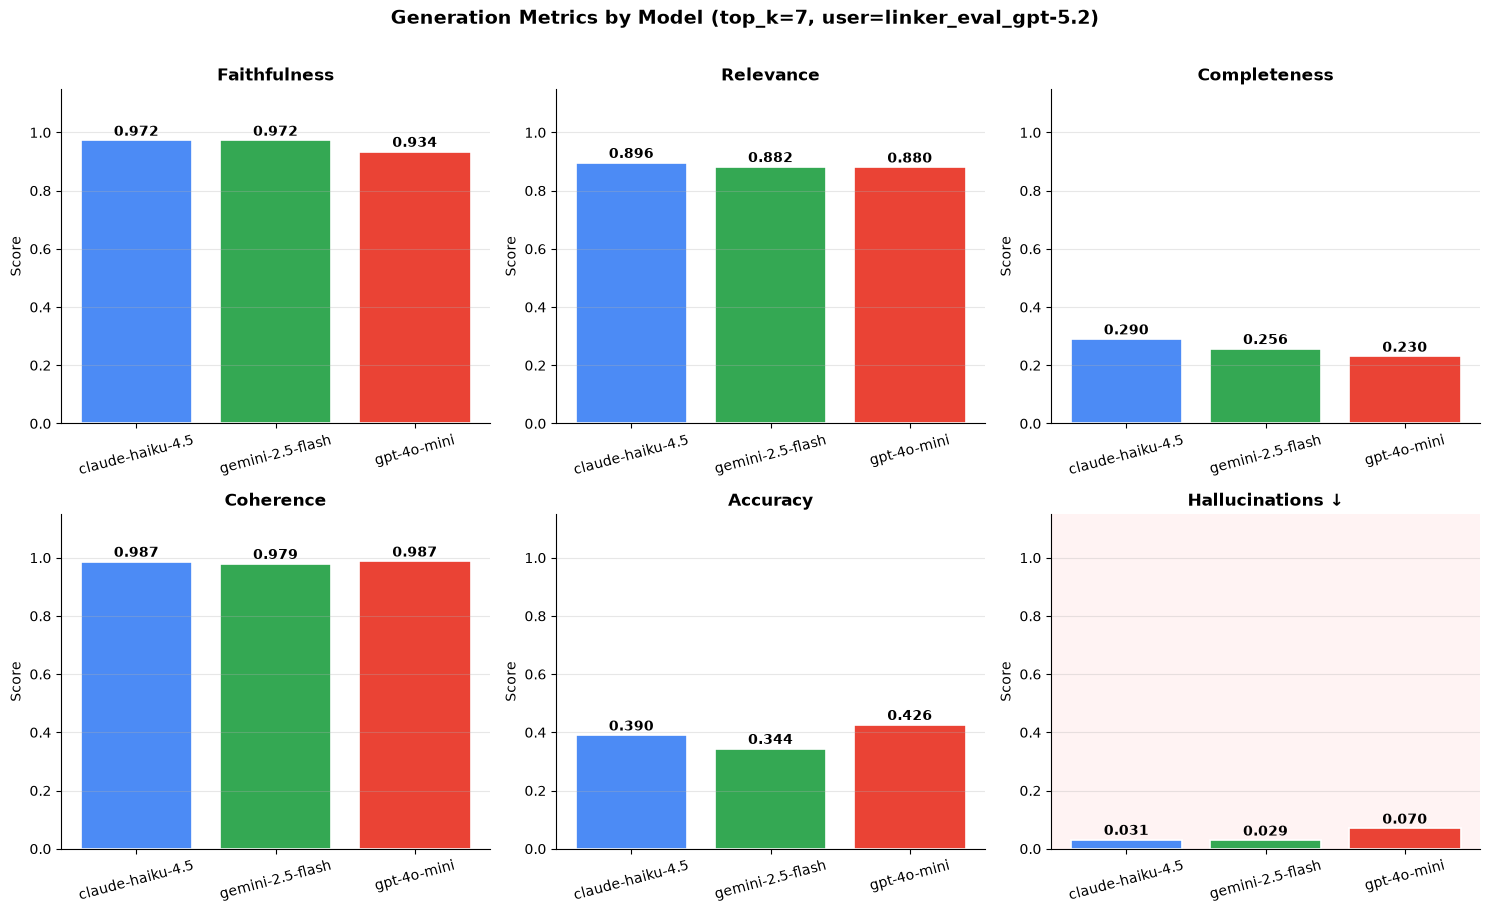

Saved generation_metrics_bar.png


In [7]:
model_labels = {
    'openai/gpt-4o-mini':          'gpt-4o-mini',
    'google/gemini-2.5-flash':     'gemini-2.5-flash',
    'anthropic/claude-haiku-4.5':  'claude-haiku-4.5',
}
palette_models = ['#4C8BF5', '#34A853', '#EA4335']

means_by_model = df_gen_raw.groupby('model_name')[EVAL_METRICS].mean()
means_by_model.index = [model_labels.get(m, m) for m in means_by_model.index]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

metric_labels_gen = {
    'faithfulness':  'Faithfulness',
    'relevance':     'Relevance',
    'completeness':  'Completeness',
    'coherence':     'Coherence',
    'accuracy':      'Accuracy',
    'hallucinations': 'Hallucinations ↓',
}

for ax, metric in zip(axes, EVAL_METRICS):
    vals  = means_by_model[metric].values
    names = list(means_by_model.index)
    bars  = ax.bar(names, vals, color=palette_models[:len(names)], edgecolor='white', linewidth=1.2)
    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width()/2, v + 0.005,
            f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold'
        )
    ax.set_title(metric_labels_gen[metric], fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=15)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)
    if metric == 'hallucinations':
        ax.set_facecolor('#FFF3F3')

fig.suptitle(f'Generation Metrics by Model (top_k={BEST_K}, user={EVAL_USER_ID})',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'generation_metrics_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved generation_metrics_bar.png')

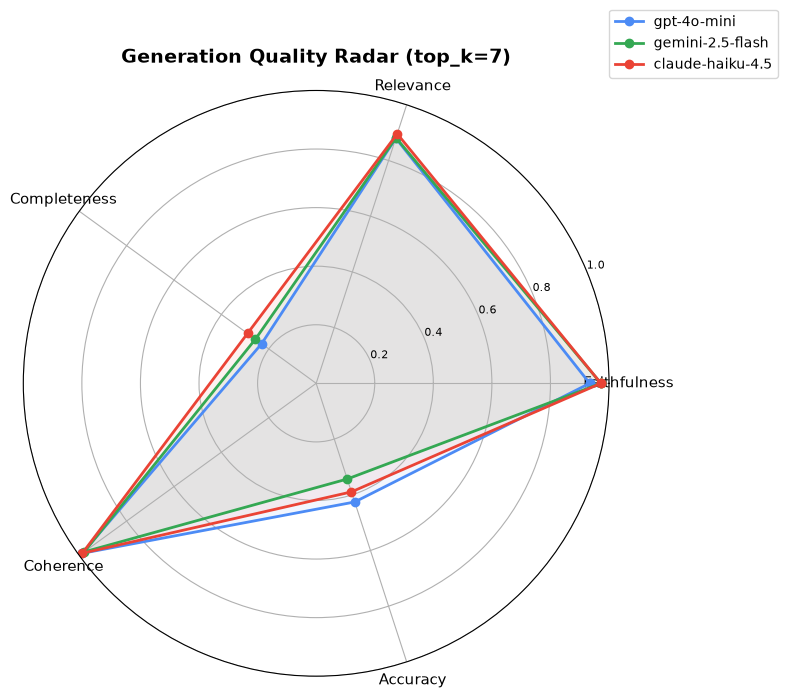

Saved generation_radar.png


In [8]:
radar_metrics = ['faithfulness', 'relevance', 'completeness', 'coherence', 'accuracy']
n_metrics = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, n_metrics, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, model in enumerate(LLM_MODELS):
    label = model_labels.get(model, model)
    if model not in df_gen_raw['model_name'].values:
        continue
    vals = df_gen_raw[df_gen_raw['model_name'] == model][radar_metrics].mean().tolist()
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, label=label, color=palette_models[i])
    ax.fill(angles, vals, alpha=0.07, color=palette_models[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels([m.capitalize() for m in radar_metrics], size=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], size=8)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15))
ax.set_title(f'Generation Quality Radar (top_k={BEST_K})', size=14, fontweight='bold', pad=20)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'generation_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved generation_radar.png')

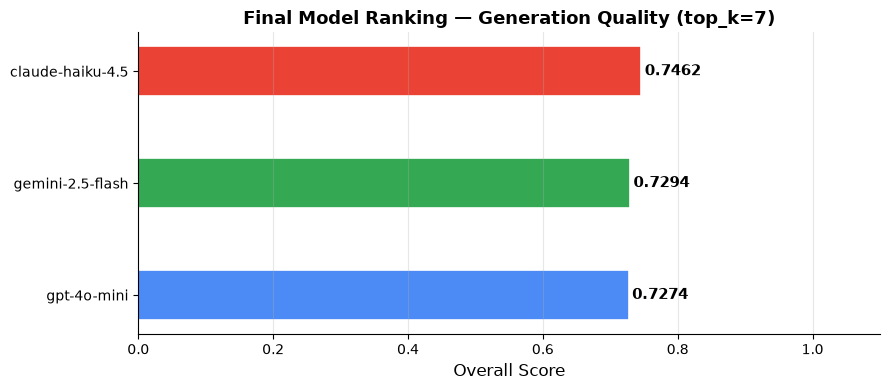

Saved generation_ranking.png


In [9]:
ranking = summary_gen[['overall_score']].copy()
ranking.index = [model_labels.get(m, m) for m in ranking.index]
ranking = ranking.sort_values('overall_score', ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
colors_rank = [palette_models[2], palette_models[1], palette_models[0]][:len(ranking)]
bars = ax.barh(
    ranking.index, ranking['overall_score'],
    color=list(reversed(colors_rank)), edgecolor='white', linewidth=1.2, height=0.45
)
for bar, v in zip(bars, ranking['overall_score']):
    ax.text(v + 0.005, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Overall Score', fontsize=12)
ax.set_title(f'Final Model Ranking — Generation Quality (top_k={BEST_K})',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.1)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'generation_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved generation_ranking.png')

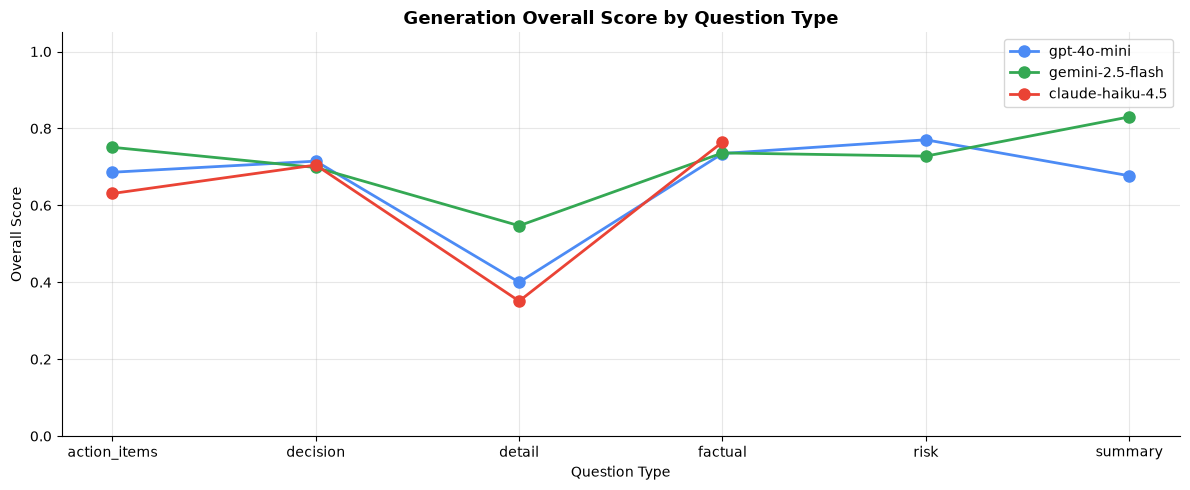

Saved generation_by_question_type.png


In [10]:
# Overall score по типам вопросов для каждой модели
df_gen_raw['overall_per_q'] = (
    df_gen_raw[['faithfulness','relevance','completeness','coherence','accuracy']].mean(axis=1) * 0.85
    + (1 - df_gen_raw['hallucinations']) * 0.15
)

by_type = df_gen_raw.groupby(['model_name', 'question_type'])['overall_per_q'].mean().reset_index()

if by_type['question_type'].nunique() > 1:
    fig, ax = plt.subplots(figsize=(12, 5))
    for i, model in enumerate(LLM_MODELS):
        label = model_labels.get(model, model)
        subset = by_type[by_type['model_name'] == model]
        ax.plot(subset['question_type'], subset['overall_per_q'], 'o-',
                label=label, color=palette_models[i], linewidth=2, markersize=8)
    ax.set_xlabel('Question Type')
    ax.set_ylabel('Overall Score')
    ax.set_ylim(0, 1.05)
    ax.set_title('Generation Overall Score by Question Type', fontsize=13, fontweight='bold')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'generation_by_question_type.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved generation_by_question_type.png')

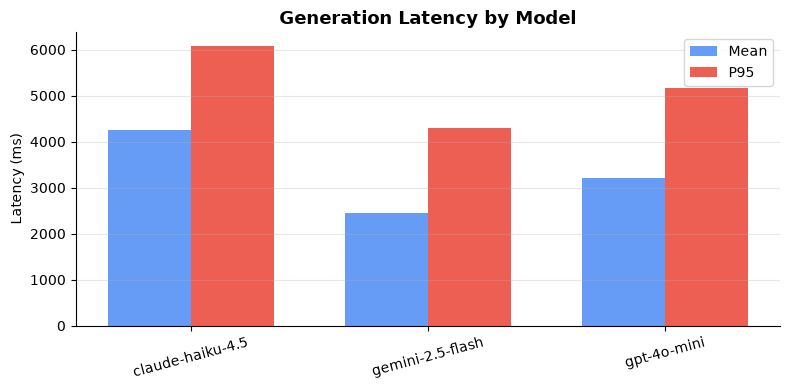

Saved generation_latency.png


In [11]:
latency_by_model = df_gen_raw.groupby('model_name')['latency_ms'].agg(['mean', lambda x: np.percentile(x, 95)])
latency_by_model.columns = ['mean_ms', 'p95_ms']
latency_by_model.index   = [model_labels.get(m, m) for m in latency_by_model.index]

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(latency_by_model))
w = 0.35
ax.bar(x - w/2, latency_by_model['mean_ms'], w, label='Mean', color='#4C8BF5', alpha=0.85)
ax.bar(x + w/2, latency_by_model['p95_ms'],  w, label='P95',  color='#EA4335', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(latency_by_model.index, rotation=15)
ax.set_ylabel('Latency (ms)')
ax.set_title('Generation Latency by Model', fontsize=13, fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'generation_latency.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved generation_latency.png')

In [12]:
best_model = summary_gen['overall_score'].idxmax()
best_score = summary_gen['overall_score'].max()

report_lines = [
    '=== RAG GENERATION EVALUATION REPORT ===',
    f'User ID:        {EVAL_USER_ID}',
    f'Best top_k:     {BEST_K} (from retrieval eval)',
    f'Judge model:    {JUDGE_MODEL}',
    f'Evaluated:      {len(df_eval)} questions × {len(LLM_MODELS)} models',
    f'Generated at:   {datetime.now().isoformat()}',
    '',
    '--- Results by model ---',
]

for model in LLM_MODELS:
    label  = model_labels.get(model, model)
    if model not in summary_gen.index:
        continue
    row    = summary_gen.loc[model]
    marker = '  ← BEST' if model == best_model else ''
    report_lines.append(f'\n[{label}]{marker}')
    for m in EVAL_METRICS:
        col   = f'{m}_mean'
        val   = row[col] if col in row.index else float('nan')
        arrow = '↓' if m == 'hallucinations' else ' '
        report_lines.append(f'  {metric_labels_gen[m]:<22} {arrow} {val:.4f}')
    report_lines.append(f'  {"Overall Score":<22}   {row["overall_score"]:.4f}')
    report_lines.append(f'  {"Latency mean (ms)":<22}   {row["latency_ms_mean"]:.0f}')

report_lines += [
    '',
    f'--- Winner ---',
    f'Best model: {best_model}  (overall_score={best_score:.4f})',
]

report_text = '\n'.join(report_lines)
print(report_text)

with open(OUTPUT_DIR / 'generation_report.txt', 'w', encoding='utf-8') as f:
    f.write(report_text)
print(f'\nReport saved: {OUTPUT_DIR / "generation_report.txt"}')

=== RAG GENERATION EVALUATION REPORT ===
User ID:        linker_eval_gpt-5.2
Best top_k:     7 (from retrieval eval)
Judge model:    openai/gpt-5.1
Evaluated:      131 questions × 3 models
Generated at:   2026-06-28T17:23:40.710785

--- Results by model ---

[gpt-4o-mini]
  Faithfulness             0.9340
  Relevance                0.8802
  Completeness             0.2302
  Coherence                0.9874
  Accuracy                 0.4260
  Hallucinations ↓       ↓ 0.0698
  Overall Score            0.7274
  Latency mean (ms)        3212

[gemini-2.5-flash]
  Faithfulness             0.9724
  Relevance                0.8818
  Completeness             0.2565
  Coherence                0.9792
  Accuracy                 0.3435
  Hallucinations ↓       ↓ 0.0288
  Overall Score            0.7294
  Latency mean (ms)        2446

[claude-haiku-4.5]  ← BEST
  Faithfulness             0.9723
  Relevance                0.8958
  Completeness             0.2898
  Coherence                0.9867
  A